# Subjective Utility, Choice, and Experimental Design

**Notebook 1 of 2 — Statistical Inference of Subjective Preferences from Choices Under Uncertainty**

This notebook sets out the conceptual framework for the project, describes the choice
experiment used to generate data, and carries out an initial, restrained exploratory
analysis. Formal statistical inference is left to Notebook 2
(`02_statistical_inference.ipynb`).

## 1. Motivation

An amount of money, a waiting time, or a probability of winning a prize can all be
measured objectively — they are numbers that do not depend on who receives them. What
is *not* observable is how much a given individual values that outcome. Two people
handed the same ₹100 note may not experience it as equally good; two people facing the
same 50/50 gamble may not find it equally attractive.

This creates a basic empirical problem. Subjective valuation — what economists call
*utility* — is central to how people make decisions, but it cannot be measured directly
with a ruler or a thermometer. The only thing a researcher can observe is the choice
that results from it.

Choices made under uncertainty are a useful setting for studying this problem, because
uncertainty forces a trade-off: accepting a gamble means giving up a certain outcome for
an uncertain one, and *how* an individual resolves that trade-off is informative about
their underlying preferences — even though those preferences are never observed
directly.

The guiding logical chain for this project is:

$$\text{Objective outcomes} \rightarrow \text{Subjective valuation} \rightarrow \text{Choice} \rightarrow \text{Observed data} \rightarrow \text{Statistical inference} \rightarrow \text{Evidence about preferences}$$

The word *evidence* is deliberate. Nothing here claims that a person's true utility
function can be recovered exactly from a small number of choices. The aim is more
modest: to ask what, if anything, repeated choices under controlled conditions can tell
us statistically about systematic differences in preference.

## 2. Utility as a Representation of Preferences

In economics, *utility* is not a claim about a psychological quantity that lives inside
a person's head. It is a convenient numerical device for **representing** preferences
over alternatives in a way that is consistent with how that person chooses.

Two related but distinct notions are useful here:

- **Ordinal utility.** A utility function that only needs to rank alternatives correctly
  ($u(A) > u(B)$ if and only if $A$ is preferred to $B$). Any increasing transformation
  of an ordinal utility function represents the same preferences.
- **Cardinal utility.** A utility function whose numerical *differences* are also
  treated as meaningful, which is required once probabilities enter the picture (see
  Section 3). Expected-utility theory relies on a cardinal representation, but the
  numbers still represent preferences over outcomes — they are not independently
  measured psychological units in the way that, say, height in centimetres is measured.

This distinction matters for how the results of this project should be read.
Estimating something that *behaves like* a utility parameter for a given participant
(Notebook 2, Section 3) is not the same as measuring their internal, subjective
experience on an objective scale. The estimate is only ever a statistical summary of
observed choices, filtered through a modelling assumption about how choices relate to
preferences.

## 3. Utility Under Uncertainty

For a lottery with outcomes $x_1, \dots, x_n$ occurring with probabilities
$p_1, \dots, p_n$ (summing to 1), expected-utility theory represents the value of the
lottery to an individual with utility function $u(\cdot)$ as

$$EU = \sum_i p_i\, u(x_i)$$

The **shape** of $u(\cdot)$ determines attitudes toward risk:

- **Risk neutrality**: $u(x)$ is linear in $x$. The individual cares only about expected
  monetary value.
- **Risk aversion**: $u(x)$ is concave. The individual prefers a certain amount over a
  risky prospect with the same expected value.
- **Risk seeking**: $u(x)$ is convex. The individual prefers some risky prospects over
  their certain equivalent.

The cell below illustrates this with three stylised utility shapes evaluated on the same
gamble, to make the idea concrete before the experiment is introduced.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys, os

sys.path.insert(0, os.path.join("..", "src"))
from analysis_helpers import (
    build_design, simulate_participants, simulate_choices, corrupt_data,
    clean_data, approximate_certainty_equivalent, cluster_bootstrap_ci,
    value_fn, prob_weight,
)

FIG_DIR = os.path.join("..", "figures")
DATA_RAW = os.path.join("..", "data", "raw")
DATA_PROC = os.path.join("..", "data", "processed")
os.makedirs(FIG_DIR, exist_ok=True)

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

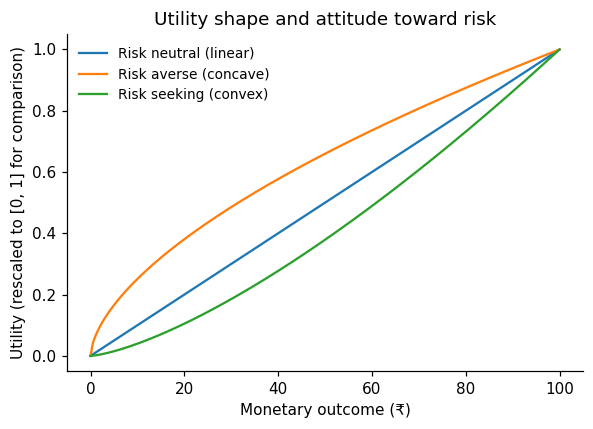

risk neutral    EU(50/50 ±100 around W=500) =   500.00   u(certain W) =   500.00   EU - u(W) = +0.00
risk averse     EU(50/50 ±100 around W=500) =    41.43   u(certain W) =    41.63   EU - u(W) = -0.20
risk seeking    EU(50/50 ±100 around W=500) =  6073.10   u(certain W) =  6005.62   EU - u(W) = +67.48


In [ ]:
# Three stylised utility shapes over the same range of monetary outcomes
x = np.linspace(0, 100, 200)
u_neutral = x
u_averse = x ** 0.6
u_seeking = np.where(x > 0, x ** 1.4 / 100 ** 0.4, 0)

fig, ax = plt.subplots(figsize=(5.5, 4))
ax.plot(x, u_neutral / u_neutral.max(), label="Risk neutral (linear)")
ax.plot(x, u_averse / u_averse.max(), label="Risk averse (concave)")
ax.plot(x, u_seeking / u_seeking.max(), label="Risk seeking (convex)")
ax.set_xlabel("Monetary outcome (₹)")
ax.set_ylabel("Utility (rescaled to [0, 1] for comparison)")
ax.set_title("Utility shape and attitude toward risk")
ax.legend(frameon=False, fontsize=9)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "01_utility_shapes.png"))
plt.show()

# A simple numerical illustration: EV(0, 50/50, ±100) = 0, but EU differs by shape.
# Utility is applied to the resulting WEALTH level (W + outcome), not to the ± outcome
# directly -- applying a curved function symmetrically to +100 and -100 and adding the
# results would cancel out by construction for any shape, which would illustrate
# nothing. Evaluating utility over wealth is also the standard, more defensible
# convention: preferences are over what you end up with, not over the label "gain" or
# "loss" attached to how you got there.
W = 500  # illustrative starting wealth
for name, alpha in [("risk neutral", 1.0), ("risk averse", 0.6), ("risk seeking", 1.4)]:
    eu = 0.5 * (W + 100) ** alpha + 0.5 * (W - 100) ** alpha
    u_certain = W ** alpha
    print(f"{name:14s}  EU(50/50 ±100 around W={W}) = {eu:8.2f}   "
          f"u(certain W) = {u_certain:8.2f}   EU - u(W) = {eu - u_certain:+.2f}")

The expected *monetary* value of the ±₹100 coin-flip gamble is zero for every
row above, by construction: it leaves wealth at $W$ on average. The expected *utility*
relative to just keeping $W$ for certain is not zero: it is negative for the concave
(risk-averse) shape, essentially zero for the linear (risk-neutral) shape (Jensen's
inequality binds with equality for a linear function), and positive for the convex
(risk-seeking) shape. This is the entire statistical opportunity the project exploits —
objectively identical gambles can produce systematically different appraisals, and
therefore different choices, depending on the shape of an unobserved function.

A related idea, used later in the experiment and analysis, is the **certainty
equivalent (CE)**: the certain amount that leaves an individual indifferent between
receiving it for sure and facing the risky prospect. For a risk-averse individual facing
a gamble with positive expected value, the CE is below the expected value; for a
risk-seeking individual, it is above.

## 4. From Theory to Statistical Question

Utility, as described above, cannot be read off directly — no instrument measures it.
What *can* be observed is a sequence of choices between a certain amount and a risky
prospect, recorded under controlled, known conditions (known probabilities, known
outcomes). This motivates the empirical strategy of the project: vary the objective
features of the choice systematically, observe what people choose, and use statistical
methods to characterise the patterns.

**Primary research question**

> Can aspects of subjective preferences be statistically inferred from observed choices
> under uncertainty?

**Secondary research questions**

1. Do individuals make systematically different choices when faced with the same
   objective outcomes?
2. Can observable choices reveal evidence of different attitudes toward risk?
3. How heterogeneous are preferences across individuals?
4. How does probability affect choices?
5. How do the size and direction of outcomes affect choices?
6. Do individuals respond differently to gains and losses?
7. How internally consistent are individual choices?
8. Can a relatively simple statistical model explain observed choices?
9. What can and cannot be inferred about subjective utility from choice data?

Notebook 1 builds the dataset needed to address these questions; Notebook 2 addresses
them directly.

## 5. Experimental Design

The experiment is a compact binary-choice task. On each trial, a participant chooses
between:

- **Option A (certain):** a guaranteed monetary amount, and
- **Option B (risky):** a lottery that pays a fixed non-zero amount with probability
  $p$, and ₹0 otherwise.

**Design dimensions**

| Dimension | Levels used |
|---|---|
| Probability $p$ | 0.10, 0.25, 0.50, 0.75, 0.90 |
| Domain | Gain (chance of winning ₹100) / Loss (chance of losing ₹100) |
| Certain amount | Three levels bracketing the expected value: $EV-10$, $EV$, $EV+10$ (clipped to a plausible range) |
| Attention check | One dominance trial per domain, where the certain option is unambiguously better than every possible lottery outcome |

This gives $5 \text{ probabilities} \times 3 \text{ certain amounts} \times 2 \text{
domains} = 30$ substantive trials, plus 2 dominance checks, for **32 trials per
participant** — short enough to complete in one sitting, while still bracketing a
certainty equivalent at each probability/domain combination (cf. Section 11 of the
project brief).

**Randomisation and order.** Trial order is randomised independently for each
participant (see `simulate_choices` in `src/analysis_helpers.py`) to avoid confounding
order with any systematic drift in attention or fatigue.

**Dominance checks.** These are not scored as "correct/incorrect" in a way that
penalises participants; they are used later purely as one input (among several) into
assessing response quality, since a participant who reliably chooses a dominated option
across many trials makes any inference about their preferences unreliable.

**Instructions (as would be given to participants).** Participants would be told that
each trial is independent, that probabilities are exactly as stated (e.g. a "25% chance"
is implemented, in a real deployment, via a transparent random draw), and that there are
no correct or incorrect answers — only their own preference between the two options.

The design below is built programmatically so that it is exactly reproducible.

In [ ]:
design = build_design()
print(f"{len(design)} trial types "
      f"({(design.is_dominance_check==False).sum()} substantive + "
      f"{design.is_dominance_check.sum()} dominance checks)")
design.head(8)

32 trial types (30 substantive + 2 dominance checks)


,trial_id,domain,probability,gain,loss,certain_amount,certain_offset,is_dominance_check
0,1,gain,0.10,100,0,0.0,-10.0,False
1,2,gain,0.10,100,0,10.0,0.0,False
2,3,gain,0.10,100,0,20.0,10.0,False
3,4,gain,0.25,100,0,15.0,-10.0,False
4,5,gain,0.25,100,0,25.0,0.0,False
5,6,gain,0.25,100,0,35.0,10.0,False
6,7,gain,0.50,100,0,40.0,-10.0,False
7,8,gain,0.50,100,0,50.0,0.0,False


## 6. Data Collection

**A real deployment of this design would recruit participants (e.g. university students
or an online panel), present the 32 trials in randomised order through a simple web
form, and record each choice along with minimal, non-identifying background
information.**

No such data-collection round was run for this exercise. Instead, the dataset used
throughout the rest of the project is **simulated**. This is stated explicitly and
repeatedly: any numbers, figures, or conclusions drawn from this dataset describe
properties of the simulation, not empirical facts about real decision-makers. The
simulation is *designed* to have the qualitative properties one would plausibly expect
from real choice data (individual heterogeneity in risk attitude, imperfect response
consistency, some sensitivity to probability and to the size of outcomes) precisely so
that the statistical methods in Notebook 2 have something realistic to work with — but
it should not be mistaken for evidence about actual human preferences.

The generating process (fully documented in `src/analysis_helpers.py`) draws, for each
simulated participant, a latent risk-curvature parameter, a loss-aversion multiplier, a
probability-weighting parameter, and a choice-consistency parameter, none of which are
retained in the exported dataset — the statistical analysis in Notebook 2 only ever sees
choices, exactly as a real researcher would.

A small amount of realistic data-quality noise (missing responses, duplicate rows, and a
few impossible field values) is then injected into the exported "raw" file, so that the
cleaning step in Section 7 is doing genuine work rather than a cosmetic pass over an
already-perfect file.

In [ ]:
N_PARTICIPANTS = 60

participants_full = simulate_participants(N_PARTICIPANTS, seed=1)
choices_true = simulate_choices(design, participants_full, seed=2)

# Raw, participant-facing file: no latent preference parameters included
participants_export = participants_full.drop(columns=[c for c in participants_full.columns if c.startswith("_")])

raw_choices = corrupt_data(choices_true, seed=3)

participants_export.to_csv(os.path.join(DATA_RAW, "participants_simulated.csv"), index=False)
raw_choices.to_csv(os.path.join(DATA_RAW, "choices_raw_simulated.csv"), index=False)

print(f"Participants: {len(participants_export)}")
print(f"Raw choice records (post data-quality corruption): {len(raw_choices)}")
raw_choices.head()

Participants: 60
Raw choice records (post data-quality corruption): 1939


,participant_id,trial_number,trial_id,domain,probability,gain,loss,certain_amount,certain_offset,is_dominance_check,choice
0,P055,12,26,loss,0.75,0,100,-65.0,-10.0,False,certain
1,P027,14,4,gain,0.25,100,0,15.0,-10.0,False,certain
2,P053,23,27,loss,0.75,0,100,-75.0,0.0,False,certain
3,P031,21,28,loss,0.75,0,100,-85.0,10.0,False,gamble
4,P010,25,12,gain,0.75,100,0,85.0,10.0,False,certain


## 7. Data Cleaning

The raw file above was deliberately corrupted with a small number of realistic issues.
Each is handled explicitly, and every observation removed is counted and reported —
nothing is dropped silently.

Steps applied (see `clean_data` in `src/analysis_helpers.py`):

1. Remove exact duplicate rows.
2. Remove rows with a missing `choice`.
3. Remove rows with an impossible `probability` (outside $(0, 1]$).
4. Remove rows with a missing or non-finite `certain_amount`.

In [ ]:
clean_choices, report = clean_data(raw_choices)
report_df = pd.DataFrame([report]).T.rename(columns={0: "count"})
print(report_df)

# Attach non-identifying participant background to the cleaned choice records
clean_choices = clean_choices.merge(participants_export, on="participant_id", how="left")

clean_choices.to_csv(os.path.join(DATA_PROC, "choices_clean.csv"), index=False)
print(f"\nClean dataset written to data/processed/choices_clean.csv "
      f"({len(clean_choices)} rows, {clean_choices.participant_id.nunique()} participants).")
clean_choices.head()

                                   count
n_raw                               1939
duplicates_removed                    19
missing_choice_removed                23
impossible_probability_removed         6
impossible_certain_amount_removed      5
n_clean                             1886

Clean dataset written to data/processed/choices_clean.csv (1886 rows, 60 participants).


,participant_id,trial_number,trial_id,domain,probability,gain,loss,certain_amount,certain_offset,is_dominance_check,choice,age_group,education,quant_background
0,P055,12,26,loss,0.75,0,100,-65.0,-10.0,False,certain,18-24,undergraduate,no
1,P027,14,4,gain,0.25,100,0,15.0,-10.0,False,certain,18-24,undergraduate,no
2,P053,23,27,loss,0.75,0,100,-75.0,0.0,False,certain,18-24,undergraduate,no
3,P031,21,28,loss,0.75,0,100,-85.0,10.0,False,gamble,18-24,undergraduate,no
4,P010,25,12,gain,0.75,100,0,85.0,10.0,False,certain,25-34,undergraduate,yes


The number of rows removed at each step is small relative to the dataset (by
construction, since the corruption rates were deliberately kept low — see
`corrupt_data`), which is itself worth noting: in this dataset, cleaning has a modest
effect on the substantive results in Notebook 2. That would not necessarily be true of a
real, messier dataset, and robustness to alternative cleaning choices is revisited in
Notebook 2, Section 10.

## 8. Exploratory Analysis

This section is deliberately restrained: descriptive summaries and a small number of
figures, each chosen to speak to one of the research questions, with no formal modelling
yet. Formal inference (confidence intervals, regression modelling, model comparison) is
left entirely to Notebook 2.

In [ ]:
substantive = clean_choices[~clean_choices.is_dominance_check].copy()
substantive["gambled"] = (substantive.choice == "gamble").astype(int)

print(f"Participants: {substantive.participant_id.nunique()}")
print(f"Substantive trials analysed: {len(substantive)}")
print(f"Overall gamble-acceptance rate: {substantive.gambled.mean():.3f}")

dom_checks = clean_choices[clean_choices.is_dominance_check].copy()
dom_checks["gambled"] = (dom_checks.choice == "gamble").astype(int)
print(f"Dominance-check gamble rate (lower is more attentive): "
      f"{dom_checks.gambled.mean():.3f}")

Participants: 60
Substantive trials analysed: 1768
Overall gamble-acceptance rate: 0.501
Dominance-check gamble rate (lower is more attentive): 0.068


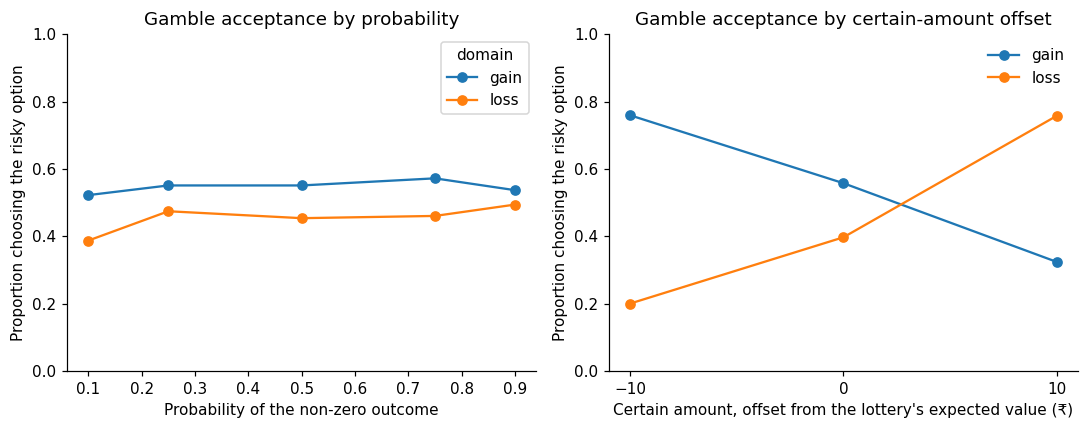

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

acc_by_p = substantive.groupby(["domain", "probability"]).gambled.mean().unstack("domain")
acc_by_p.plot(marker="o", ax=axes[0])
axes[0].set_xlabel("Probability of the non-zero outcome")
axes[0].set_ylabel("Proportion choosing the risky option")
axes[0].set_title("Gamble acceptance by probability")
axes[0].set_ylim(0, 1)

acc_by_off = substantive.groupby(["domain", "certain_offset"]).gambled.mean()
for dom in ["gain", "loss"]:
    s = acc_by_off[dom].sort_index()
    axes[1].plot(s.index, s.values, marker="o", label=dom)
axes[1].set_xlabel("Certain amount, offset from the lottery's expected value (₹)")
axes[1].set_ylabel("Proportion choosing the risky option")
axes[1].set_title("Gamble acceptance by certain-amount offset")
axes[1].set_xticks([-10, 0, 10])
axes[1].legend(frameon=False)
axes[1].set_ylim(0, 1)

fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "02_acceptance_by_probability_and_certain_amount.png"))
plt.show()

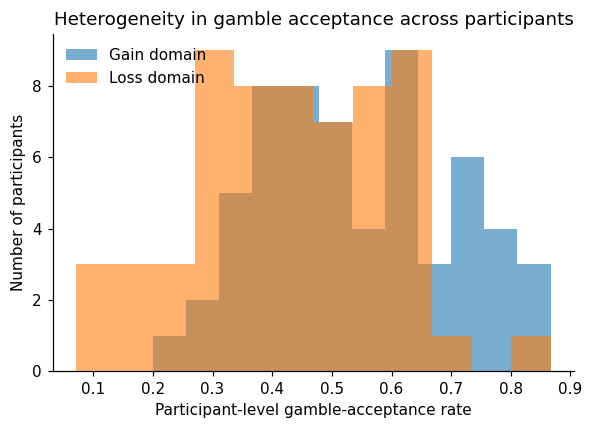

domain       gain       loss
count   60.000000  60.000000
mean     0.546911   0.453492
std      0.163506   0.170555
min      0.200000   0.071429
25%      0.400000   0.333333
50%      0.533333   0.466667
75%      0.666667   0.600000
max      0.866667   0.866667


In [ ]:
participant_rates = substantive.groupby(["participant_id", "domain"]).gambled.mean().unstack("domain")

fig, ax = plt.subplots(figsize=(5.5, 4))
ax.hist(participant_rates["gain"], bins=12, alpha=0.6, label="Gain domain")
ax.hist(participant_rates["loss"], bins=12, alpha=0.6, label="Loss domain")
ax.set_xlabel("Participant-level gamble-acceptance rate")
ax.set_ylabel("Number of participants")
ax.set_title("Heterogeneity in gamble acceptance across participants")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "03_participant_heterogeneity.png"))
plt.show()

print(participant_rates.describe())

**What patterns appear before formal inference?**

- Gamble acceptance is visibly related to how the certain amount sits relative to the
  expected value of the lottery — more generous certain offers pull choices away from
  the risky option, as a basic sanity check on the design would require.
- Acceptance rates are far from either 0 or 1 for most participants, and the histogram
  above shows a spread across individuals rather than a single shared rate — consistent
  with heterogeneous preferences, though not yet a statistical test of that claim.
- The dominance-check rate is low, suggesting most simulated responses are not simply
  random noise, though it is not exactly zero either.
- Whether gains and losses are treated differently, whether this reflects "loss
  aversion" specifically, and how much of the individual variation is systematic rather
  than sampling noise are all questions that require the more careful treatment in
  Notebook 2 — the patterns above are suggestive, not conclusive.